# K-Means и K-Means++ — Кластеризация

**K-Means** разбивает данные на *k* кластеров, минимизируя внутрикластерную сумму квадратов отклонений (WCSS). **K-Means++** улучшает инициализацию центроидов: каждый следующий центроид выбирается с вероятностью, пропорциональной квадрату расстояния до уже выбранных. Это снижает риск попасть в плохой локальный минимум и ускоряет сходимость. Алгоритм итеративно назначает точки к ближайшему центроиду и пересчитывает центроиды до стабилизации.

**Датасет:** Mall Customer Segmentation — данные покупателей торгового центра (возраст, доход, индекс трат).

## 2. Используемые библиотеки

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

## 3. Описание и демонстрация датасета

In [4]:
df = pd.read_csv('./Mall_Customers.csv')
print("Форма датасета:", df.shape)
print("\nПервые 10 строк:")
print(df.head(10).to_string())
print("\nОписательная статистика:")
print(df.describe().round(2).to_string())
print("\nПропущенные значения:")
print(df.isnull().sum())
print("\nРаспределение по полу:")
print(df['Gender'].value_counts())

Форма датасета: (200, 5)

Первые 10 строк:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72

Описательная статистика:
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean      

## 4. Предварительная обработка

In [5]:
# Кодирование пола и выбор признаков для кластеризации
df['Gender_enc'] = (df['Gender'] == 'Male').astype(int)

# Для основной кластеризации — доход и индекс трат (классический выбор)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X_full = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_enc']].values

scaler      = StandardScaler()
scaler_full = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_full_scaled = scaler_full.fit_transform(X_full)

print("Признаки для кластеризации:", ['Annual Income (k$)', 'Spending Score (1-100)'])
print("Форма X_scaled:", X_scaled.shape)
print("\nДанные после масштабирования (первые 5 строк):")
print(pd.DataFrame(X_scaled, columns=['Income_sc','Score_sc']).head().round(3).to_string())

Признаки для кластеризации: ['Annual Income (k$)', 'Spending Score (1-100)']
Форма X_scaled: (200, 2)

Данные после масштабирования (первые 5 строк):
   Income_sc  Score_sc
0     -1.739    -0.435
1     -1.739     1.196
2     -1.701    -1.716
3     -1.701     1.040
4     -1.663    -0.396


## 5. Тепловая карта корреляций

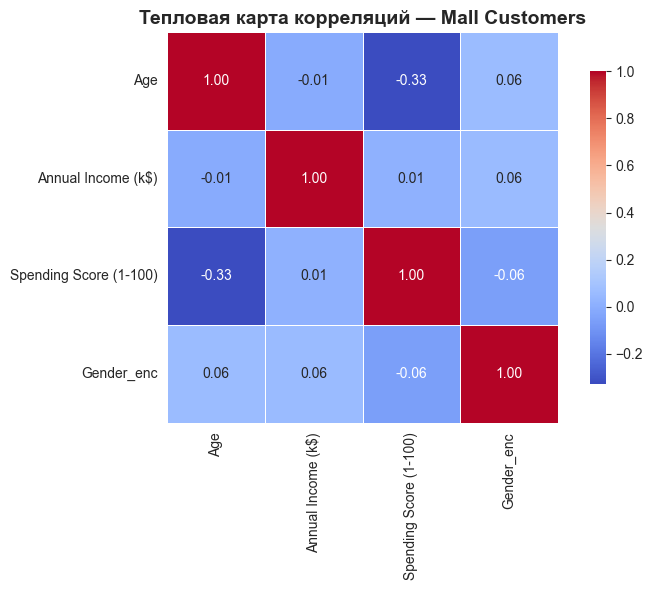

In [6]:
plt.figure(figsize=(8, 6))
corr = df[['Age','Annual Income (k$)','Spending Score (1-100)','Gender_enc']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляций — Mall Customers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Обучение — метод локтя и силуэт

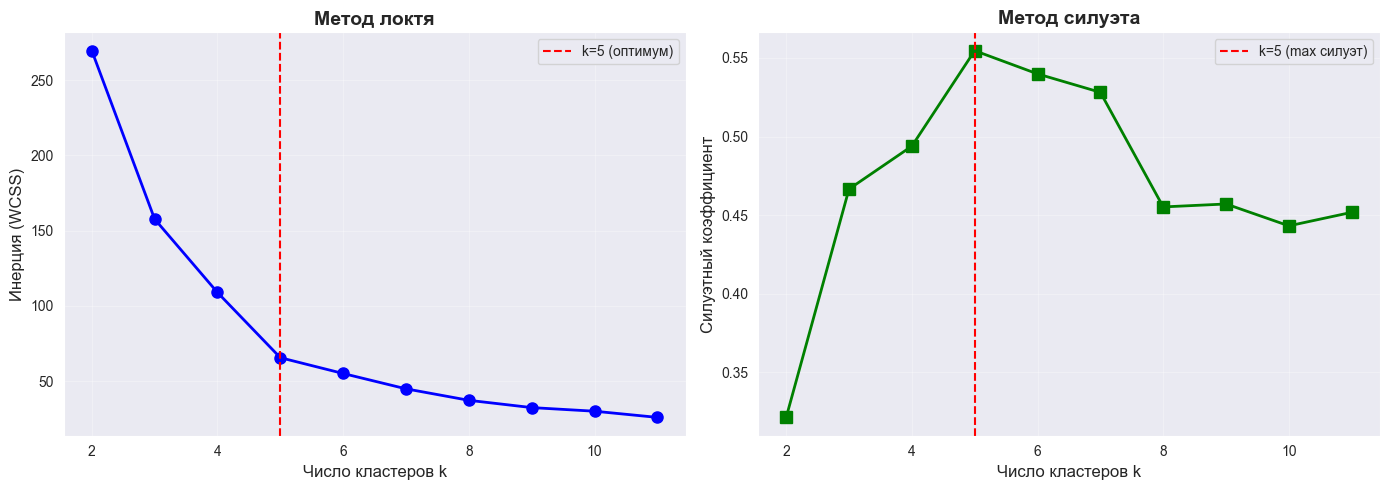

Оптимальное k по силуэту: 5, коэффициент = 0.5547


In [7]:
inertia, silhouettes = [], []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Число кластеров k', fontsize=12)
axes[0].set_ylabel('Инерция (WCSS)', fontsize=12)
axes[0].set_title('Метод локтя', fontsize=14, fontweight='bold')
axes[0].axvline(x=5, color='red', linestyle='--', label='k=5 (оптимум)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'gs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Число кластеров k', fontsize=12)
axes[1].set_ylabel('Силуэтный коэффициент', fontsize=12)
axes[1].set_title('Метод силуэта', fontsize=14, fontweight='bold')
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'k={best_k} (max силуэт)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Оптимальное k по силуэту: {best_k}, коэффициент = {max(silhouettes):.4f}")

In [8]:
# Финальные модели
km_rand = KMeans(n_clusters=5, init='random',   n_init=10, random_state=42)
km_plus = KMeans(n_clusters=5, init='k-means++',n_init=10, random_state=42)
labels_rand = km_rand.fit_predict(X_scaled)
labels_plus = km_plus.fit_predict(X_scaled)

for name, km, lbl in [('K-Means (random)', km_rand, labels_rand), ('K-Means++', km_plus, labels_plus)]:
    print(f"=== {name} ===")
    print(f"  Инерция: {km.inertia_:.2f}  |  Силуэт: {silhouette_score(X_scaled, lbl):.4f}  |  Итераций: {km.n_iter_}")

=== K-Means (random) ===
  Инерция: 65.57  |  Силуэт: 0.5547  |  Итераций: 10
=== K-Means++ ===
  Инерция: 65.57  |  Силуэт: 0.5547  |  Итераций: 4


## 7. Прогнозы модели

In [9]:
df['KMeans_cluster']   = labels_rand
df['KMeanspp_cluster'] = labels_plus
print("Размер кластеров (K-Means++):")
print(df['KMeanspp_cluster'].value_counts().sort_index())
print("\nСредние значения по кластерам (K-Means++):")
print(df.groupby('KMeanspp_cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(1).to_string())

Размер кластеров (K-Means++):
KMeanspp_cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Средние значения по кластерам (K-Means++):
                   Age  Annual Income (k$)  Spending Score (1-100)
KMeanspp_cluster                                                  
0                 42.7                55.3                    49.5
1                 32.7                86.5                    82.1
2                 25.3                25.7                    79.4
3                 41.1                88.2                    17.1
4                 45.2                26.3                    20.9


## 8. Графики результатов

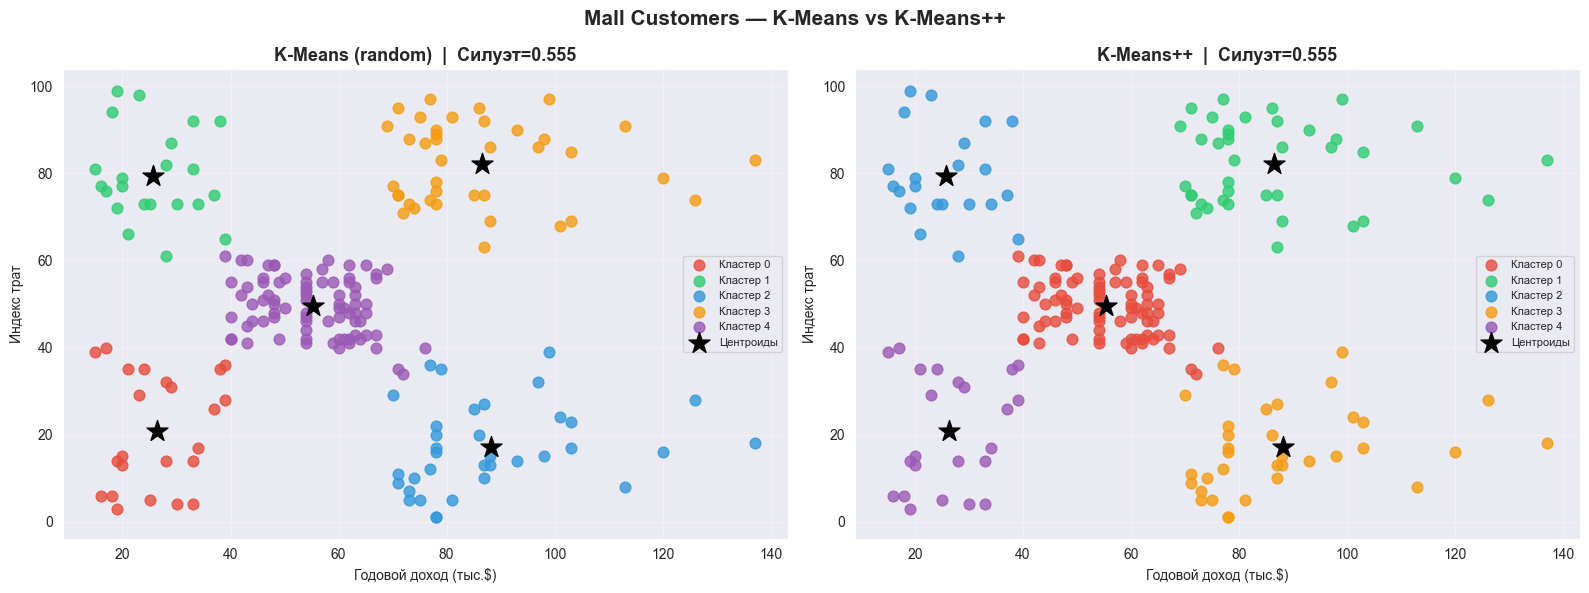

In [10]:
colors = ['#E74C3C','#2ECC71','#3498DB','#F39C12','#9B59B6']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, lbl, km) in zip(axes, [
        ('K-Means (random)', labels_rand, km_rand),
        ('K-Means++',        labels_plus, km_plus)]):
    for i in range(5):
        mask = lbl == i
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], s=60, alpha=0.8, label=f'Кластер {i}')
    c_inv = scaler.inverse_transform(km.cluster_centers_)
    ax.scatter(c_inv[:, 0], c_inv[:, 1], c='black', s=250, marker='*', zorder=5, label='Центроиды')
    ax.set_xlabel('Годовой доход (тыс.$)'); ax.set_ylabel('Индекс трат')
    ax.set_title(f'{name}  |  Силуэт={silhouette_score(X_scaled, lbl):.3f}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Mall Customers — K-Means vs K-Means++', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

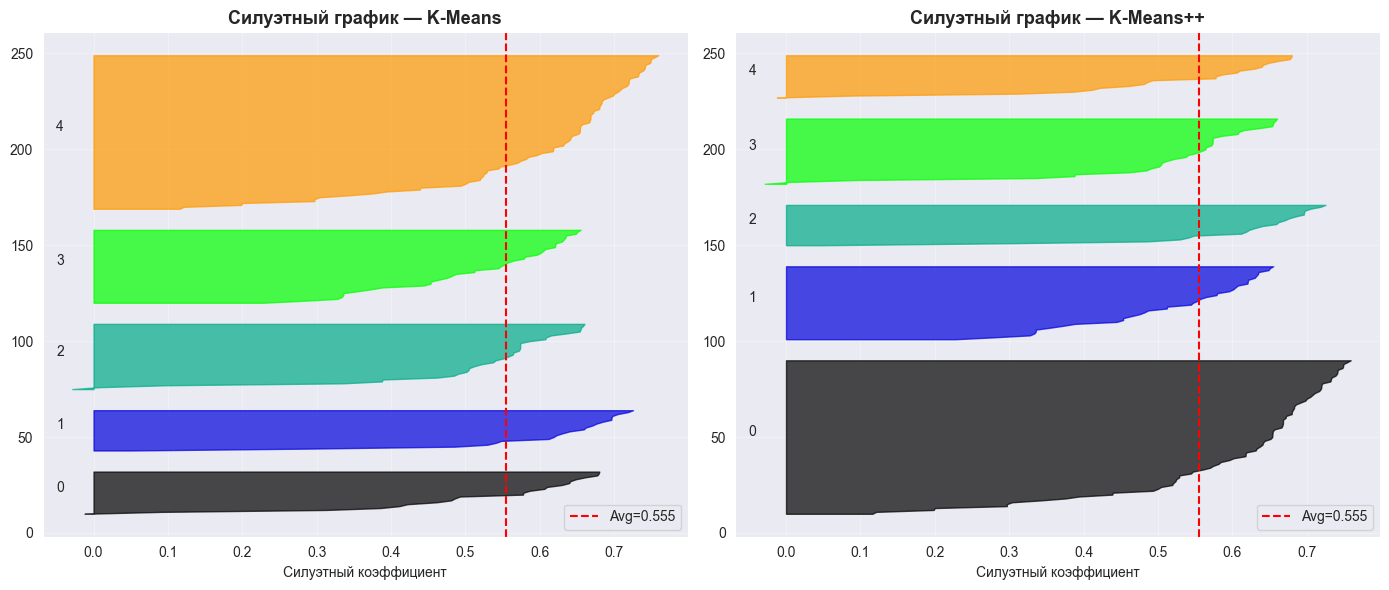

In [11]:
# Силуэтные графики
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, lbl) in zip(axes,[('K-Means', labels_rand),('K-Means++', labels_plus)]):
    sample_sil = silhouette_samples(X_scaled, lbl)
    y_lower = 10
    for i in range(5):
        vals = np.sort(sample_sil[lbl == i])
        y_upper = y_lower + len(vals)
        color = cm.nipy_spectral(float(i)/5)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=color)
        ax.text(-0.05, y_lower + 0.5*len(vals), str(i))
        y_lower = y_upper + 10
    avg = silhouette_score(X_scaled, lbl)
    ax.axvline(x=avg, color='red', linestyle='--', label=f'Avg={avg:.3f}')
    ax.set_title(f'Силуэтный график — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Силуэтный коэффициент'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()